## **Problem Statement**

### **Business Context**

The advent of e-news, or electronic news, portals has offered us a great opportunity to quickly get updates on the day-to-day events occurring globally. The information on these portals is retrieved electronically from online databases, processed using a variety of software, and then transmitted to the users. There are multiple advantages of transmitting news electronically, like faster access to the content and the ability to utilize different technologies such as audio, graphics, video, and other interactive elements that are either not being used or aren’t common yet in traditional newspapers.

E-news Express, an online news portal, aims to expand its business by acquiring new subscribers. With every visitor to the website taking certain actions based on their interest, the company plans to analyze these actions to understand user interests and determine how to drive better engagement. The executives at E-news Express believe that there has been a decline in new monthly subscribers compared to the past year because the current webpage is not designed well enough in terms of the outline & recommended content to keep customers engaged long enough to decide to subscribe.






### **Objective**

The design team of the company has researched and created a new landing page that has a new outline & more relevant content compared to the old page. To test the effectiveness of the new landing page in gathering new subscribers, the Data Science team experimented by randomly selecting 100 users and dividing them equally into two groups. The existing landing page was served to the first group (control group) and the new landing page to the second group (treatment group). Data regarding the interaction of users in both groups with the two versions of the landing page was collected. Being a data scientist in E-news Express, you have been asked to explore the data and perform a statistical analysis (at a significance level of 5%) to determine the effectiveness of the new landing page in gathering new subscribers for the news portal.

### **Data Dictionary**

The data contains information regarding the interaction of users in both groups with the two versions of the landing page.

user_id - Unique user ID of the person visiting the website
group - Whether the user belongs to the first group (control) or the second group (treatment)
landing_page - Whether the landing page is new or old
time_spent_on_the_page - Time (in minutes) spent by the user on the landing page
converted - Whether the user gets converted to a subscriber of the news portal or not
language_preferred - language chosen by the user to view the landing page


### **Solution Approach**

To solve the problem we need to answer the following questions:
* Do the users spend more time on the new landing page than on the existing landing page?
* Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?
* Does the converted status depend on the preferred language?
* Is the time spent on the new page the same for the different language users?

## **Let us start by importing the required libraries**

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 scipy==1.16.2 -q --user


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python3 -m pip install --upgrade pip


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

## **Import necessary packages and the data**

In [2]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Library to help with statistical analysis
import scipy.stats as stats

## **Loading the dataset**

In [3]:
# read the dataset
df=pd.read_csv('/root/ashiravi/abtest.csv')

## **Data Overview**

### **Basic data checks**

In [4]:
print("Dataset shape (rows, columns):", df.shape)

print("\nColumn names:")
print(list(df.columns))

print("\nData types & non-null counts:")
df.info()

print("\nMissing values per column:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate user_id:", df["user_id"].duplicated().sum())

print("\nUnique values (categorical columns):")
for col in ["group", "landing_page", "converted", "language_preferred"]:
    print(f"{col}: {df[col].unique()}")

Dataset shape (rows, columns): (100, 6)

Column names:
['user_id', 'group', 'landing_page', 'time_spent_on_the_page', 'converted', 'language_preferred']

Data types & non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB

Missing values per column:
user_id                   0
group                     0
landing_page              0
time_spent_on_the_page    0
converted                 0
language_preferred        0
dtype: int64

Duplicate rows: 0

### **Check alignment of group and landing_page**

In [5]:
display(pd.crosstab(df["group"], df["landing_page"]))

landing_page,new,old
group,,
control,0,50
treatment,50,0


### **Check Basic descriptive statistics**

In [6]:
print("\nSummary statistics for time_spent_on_the_page:")
display(df["time_spent_on_the_page"].describe())

print("\nCounts for categorical variables:")
for col in ["group", "landing_page", "converted", "language_preferred"]:
    display(df[col].value_counts(dropna=False).to_frame(name="count"))


Summary statistics for time_spent_on_the_page:


count    100.000000
mean       5.377800
std        2.378166
min        0.190000
25%        3.880000
50%        5.415000
75%        7.022500
max       10.710000
Name: time_spent_on_the_page, dtype: float64


Counts for categorical variables:


,count
control,50
treatment,50


,count
old,50
new,50


,count
yes,54
no,46


,count
Spanish,34
French,34
English,32


### **Conversion rate overall and by page**

In [7]:
df["converted_flag"] = (df["converted"].str.lower() == "yes").astype(int)

print("\nOverall conversion rate:")
print(f"{df['converted_flag'].mean():.3f}")

print("\nConversion rate by landing page:")
display(df.groupby("landing_page")["converted_flag"].agg(["mean", "sum", "count"]).rename(columns={"mean": "conversion_rate"}))



Overall conversion rate:
0.540

Conversion rate by landing page:


,conversion_rate,sum,count
landing_page,,,
new,0.66,33,50
old,0.42,21,50


## **Exploratory data analysis**

## **Univariate analysis**

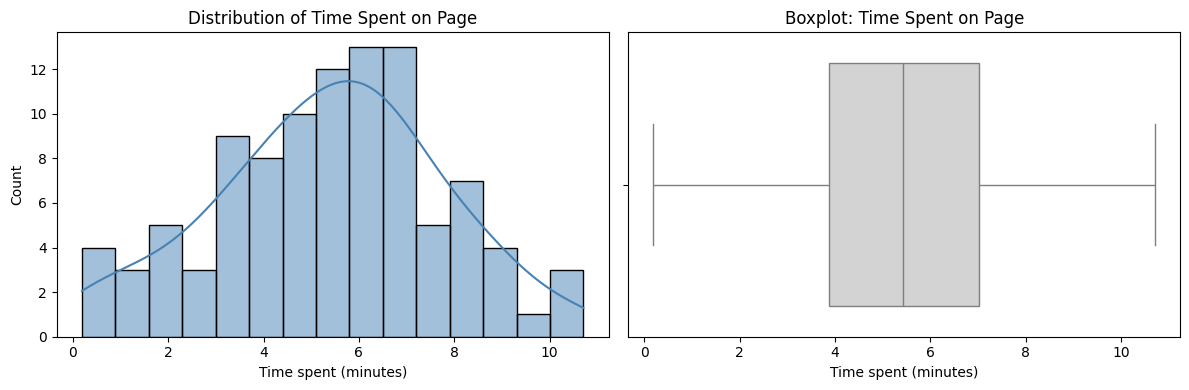

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["time_spent_on_the_page"], bins=15, kde=True, color="steelblue")
plt.title("Distribution of Time Spent on Page")
plt.xlabel("Time spent (minutes)")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["time_spent_on_the_page"], color="lightgray")
plt.title("Boxplot: Time Spent on Page")
plt.xlabel("Time spent (minutes)")

plt.tight_layout()
plt.show()

#### Observations
- The data follows a roughly normal distribution, centered around a median of approximately 5.5 minutes.
- Most users spend between 4 and 7 minutes on the page.
- Time spent ranges from nearly 0 to 11 minutes, with no statistical outliers detected.

### **Categorical distributions**

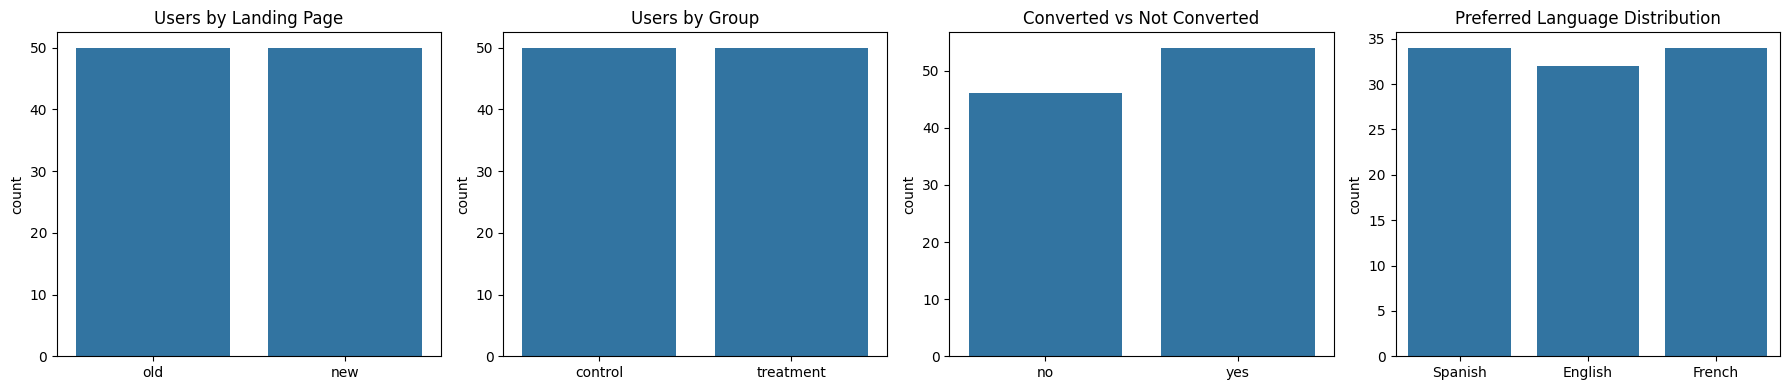

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
sns.countplot(data=df, x="landing_page", ax=axes[0])
axes[0].set_title("Users by Landing Page")

sns.countplot(data=df, x="group", ax=axes[1])
axes[1].set_title("Users by Group")

sns.countplot(data=df, x="converted", ax=axes[2])
axes[2].set_title("Converted vs Not Converted")

sns.countplot(data=df, x="language_preferred", ax=axes[3])
axes[3].set_title("Preferred Language Distribution")

for ax in axes:
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

#### Observations
- The data is perfectly split with 50 users each for landing pages (old vs. new) and experimental groups (control vs. treatment)
- More users converted (~54) than those who did not (~46), indicating a positive overall conversion trend.
- User preference is nearly evenly distributed across Spanish, French, and English, ensuring diverse linguistic representation.

## **Bivariate analysis**

### Time spent by landing page

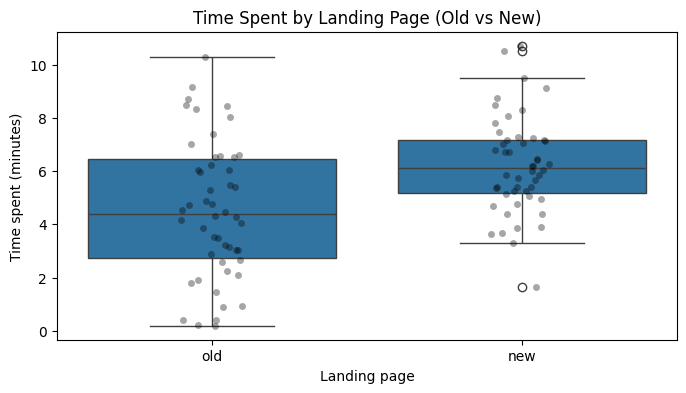


Time spent summary by landing page:


,mean,median,std,min,max,count
landing_page,,,,,,
new,6.2232,6.105,1.817031,1.65,10.71,50
old,4.5324,4.380,2.581975,0.19,10.30,50


In [10]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="landing_page", y="time_spent_on_the_page")
sns.stripplot(data=df, x="landing_page", y="time_spent_on_the_page", color="black", alpha=0.35)
plt.title("Time Spent by Landing Page (Old vs New)")
plt.xlabel("Landing page")
plt.ylabel("Time spent (minutes)")
plt.show()

print("\nTime spent summary by landing page:")
display(df.groupby("landing_page")["time_spent_on_the_page"].agg(["mean", "median", "std", "min", "max", "count"]))


#### Observations
- Users spend significantly more time on the new landing page (mean 6.22 min) compared to the old page (mean 4.53 min).
- The new page has a lower standard deviation (1.82 vs. 2.58), indicating that user engagement is more predictable and uniform.
- The new page has a much higher minimum time spent (1.65 min vs. 0.19 min), suggesting it is more effective at preventing immediate bounces than the old page.

### Conversion rate by landing page

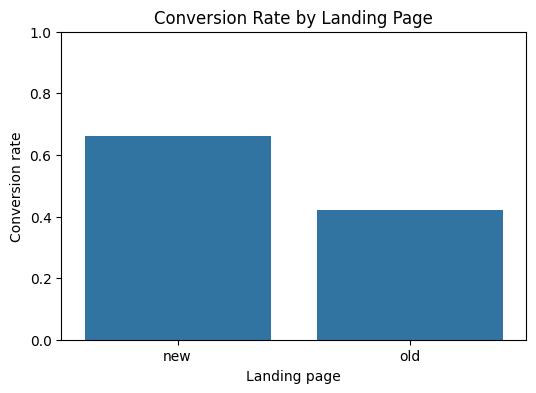


Conversion contingency table (landing_page vs converted):


converted,no,yes,All
landing_page,,,
new,17,33,50
old,29,21,50
All,46,54,100


In [11]:
conv_by_page = df.groupby("landing_page")["converted_flag"].mean().reset_index()

plt.figure(figsize=(6, 4))
sns.barplot(data=conv_by_page, x="landing_page", y="converted_flag")
plt.title("Conversion Rate by Landing Page")
plt.xlabel("Landing page")
plt.ylabel("Conversion rate")
plt.ylim(0, 1)
plt.show()

print("\nConversion contingency table (landing_page vs converted):")
display(pd.crosstab(df["landing_page"], df["converted"], margins=True))

#### Observations
- The new landing page has a significantly higher conversion rate of 33 out of 50 compared to the old page, which has a conversion rate of 21 out of 50.
- The new landing page is substantially more successful at converting users than the old version.


### Conversion vs language

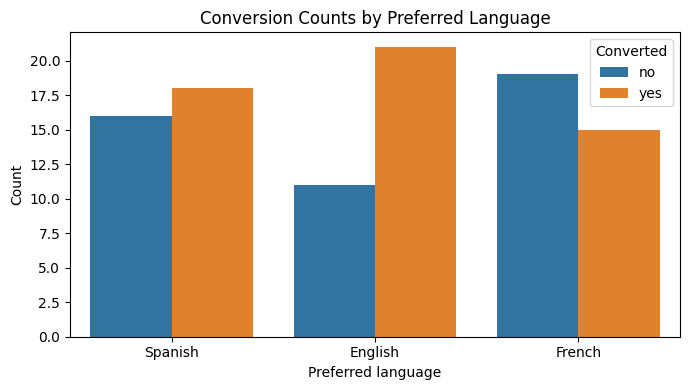


Conversion rate by language:


,conversion_rate,sum,count
language_preferred,,,
English,0.656250,21,32
French,0.441176,15,34
Spanish,0.529412,18,34



Contingency table (language_preferred vs converted):


converted,no,yes,All
language_preferred,,,
English,11,21,32
French,19,15,34
Spanish,16,18,34
All,46,54,100


In [12]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="language_preferred", hue="converted")
plt.title("Conversion Counts by Preferred Language")
plt.xlabel("Preferred language")
plt.ylabel("Count")
plt.legend(title="Converted")
plt.tight_layout()
plt.show()

print("\nConversion rate by language:")
display(df.groupby("language_preferred")["converted_flag"].agg(["mean", "sum", "count"]).rename(columns={"mean": "conversion_rate"}))

print("\nContingency table (language_preferred vs converted):")
display(pd.crosstab(df["language_preferred"], df["converted"], margins=True))


#### Observations
- English speakers have the highest conversions significantly outnumbering non-conversions (21 vs 11)
- Spanish speakers follow with a 52.9% conversion rate, while French speakers have the lowest at 44.1%.
- Language preference appears to influence conversion, with the current content being most effective for English-speaking users.


### Time spent on NEW page by language

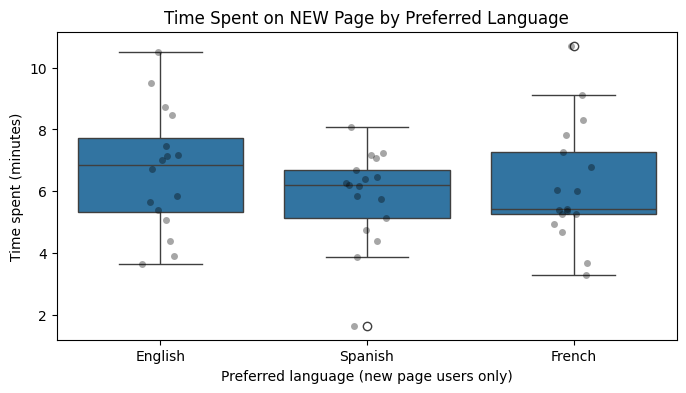


Time spent summary on NEW page by language:


,mean,median,std,min,max,count
language_preferred,,,,,,
English,6.663750,6.865,1.984150,3.65,10.50,16
French,6.196471,5.420,1.933394,3.30,10.71,17
Spanish,5.835294,6.200,1.525656,1.65,8.08,17


In [13]:
df_new = df[df["landing_page"] == "new"].copy()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df_new, x="language_preferred", y="time_spent_on_the_page")
sns.stripplot(data=df_new, x="language_preferred", y="time_spent_on_the_page", color="black", alpha=0.35)
plt.title("Time Spent on NEW Page by Preferred Language")
plt.xlabel("Preferred language (new page users only)")
plt.ylabel("Time spent (minutes)")
plt.show()

print("\nTime spent summary on NEW page by language:")
display(df_new.groupby("language_preferred")["time_spent_on_the_page"].agg(["mean", "median", "std", "min", "max", "count"]))


#### Observations
- English speakers spend the most time on the new page, with the highest mean (6.66 min) and median (6.86 min).
- Spanish speakers spend the least time on average (5.83 min) but show the most consistent behavior (lowest standard deviation).
- French speakers have the lowest median time (5.42 min) but exhibit high variability, including notable high-engagement outliers.
- Engagement is relatively similar across languages, though English-speaking users tend to stay on the new page the longest.

## **Insights from Exploratory data analysis**

**Superior Performance of the New Landing Page**
- Engagement: The new page significantly outperforms the old one, with users spending ~37% more time on it (6.22 vs. 4.53 minutes).
- Retention: The higher minimum time spent on the new page (1.65 min) compared to the old page (0.19 min) indicates that the new design is much more effective at reducing immediate bounces.
- Conversion: The new page is the primary driver of success, achieving a 66% conversion rate compared to only 42% for the old page.


**Language-Specific Engagement and Conversion**
- English Optimization: The current content is most effective for English speakers, who not only spend the most time on the page (6.66 min) but also have the highest conversion count (21 vs. 11).
- Localization Opportunity: While Spanish speakers are the most consistent in their behavior, French speakers have the lowest conversion rate (44.1%) and the lowest median time spent. This suggests that the French version of the page may benefit from content optimization or better localization to improve engagement.


**Stability and Predictability of User Behavior**
- Consistent Engagement: The overall time spent follows a normal distribution, with most users staying for 4 to 7 minutes. This predictability allows for reliable forecasting of user behavior.
- Uniformity on New Page: Engagement on the new page is more uniform and predictable (lower standard deviation) than on the old page, meaning the new design provides a more consistent user experience across the board.


**Experimental Integrity**
- Robust Testing: The insights are highly reliable because the study used a perfectly balanced experimental design (50/50 split) and a linguistically diverse sample, ensuring that the results are not biased by group size or language dominance.


##### Conclusion

The new landing page is a significant success, effectively increasing both the time users spend on the site and the likelihood of conversion. While the page performs well overall, there is a clear opportunity to further boost results by tailoring content more effectively for Spanish and French-speaking users to match the high performance seen with English speakers.  

## **Hypothesis Test 1 - If users spend more time on the new landing page than the old landing page**

In [14]:
# Significance level (alpha)
alpha = 0.05

### **Visual analysis**

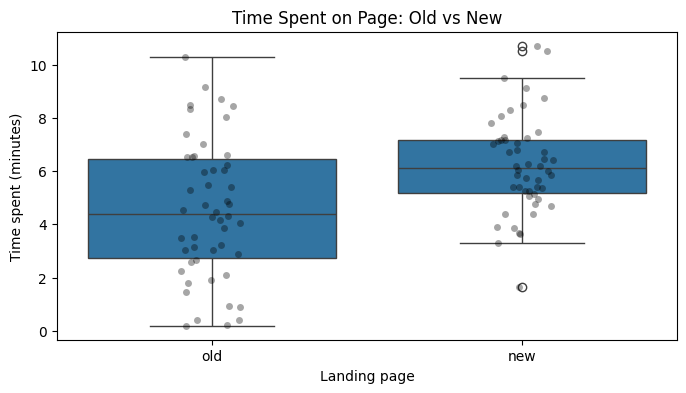

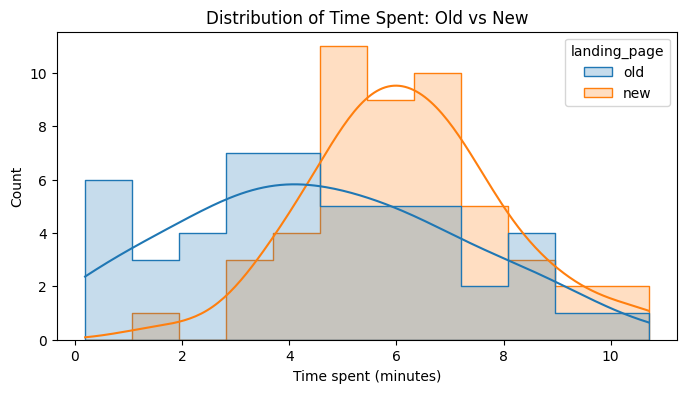

In [15]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="landing_page", y="time_spent_on_the_page")
sns.stripplot(data=df, x="landing_page", y="time_spent_on_the_page", color="black", alpha=0.35)
plt.title("Time Spent on Page: Old vs New")
plt.xlabel("Landing page")
plt.ylabel("Time spent (minutes)")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="time_spent_on_the_page", hue="landing_page", kde=True, bins=12, element="step")
plt.title("Distribution of Time Spent: Old vs New")
plt.xlabel("Time spent (minutes)")
plt.ylabel("Count")
plt.show()

#### Observations
- The new page significantly shifts user engagement to the right, with a higher median time spent.
- The new page has far fewer low-engagement sessions (0–3 minutes), suggesting it is more effective at preventing immediate bounces.

### **Formulate hypotheses**

### H0 (null):   Mean time on new page <= mean time on old page
### H1 (alt):    Mean time on new page  > mean time on old page

### **Data collection & preparation**

In [16]:
time_old = df.loc[df["landing_page"] == "old", "time_spent_on_the_page"].dropna()
time_new = df.loc[df["landing_page"] == "new", "time_spent_on_the_page"].dropna()

print("\nSample sizes:")
print("Old page n =", time_old.shape[0])
print("New page n =", time_new.shape[0])

print("\nGroup summaries:")
print(f"Old page: mean={time_old.mean():.3f}, std={time_old.std(ddof=1):.3f}")
print(f"New page: mean={time_new.mean():.3f}, std={time_new.std(ddof=1):.3f}")


Sample sizes:
Old page n = 50
New page n = 50

Group summaries:
Old page: mean=4.532, std=2.582
New page: mean=6.223, std=1.817


#### Observations
- Both the old and new pages have an equal sample size of n=50.
- The new page shows a significantly higher mean time spent (6.223) compared to the old page (4.532).
- The new page has a lower standard deviation (1.817 vs. 2.582), indicating that user engagement is more uniform and predictable than on the old page.

### **Selecting appropriate test**

In [17]:
# We compare means of two independent groups -> independent two-sample t-test.
# Use Welch's t-test (equal_var=False) to avoid assuming equal variances.
# Since H1 is "new > old", we use a ONE-TAILED test.
t_stat, p_two_tailed = stats.ttest_ind(time_new, time_old, equal_var=False)

# Convert to one-tailed p-value for the "greater" alternative
p_one_tailed = p_two_tailed / 2 if t_stat > 0 else 1 - (p_two_tailed / 2)

print("\nTest used: Welch's two-sample t-test (independent samples), one-tailed (new > old)")
print(f"t-statistic = {t_stat:.4f}")
print(f"two-tailed p-value = {p_two_tailed:.6f}")
print(f"one-tailed p-value (new > old) = {p_one_tailed:.6f}")


Test used: Welch's two-sample t-test (independent samples), one-tailed (new > old)
t-statistic = 3.7868
two-tailed p-value = 0.000278
one-tailed p-value (new > old) = 0.000139


### **Inference based on p-value**

- Reject H0 at alpha=0.05.
- There is statistically significant evidence that users spend MORE time on the NEW landing page than on the OLD landing page.

## **Hypothesis Test 2 - Is conversion rate on the NEW page greater than conversion rate on the OLD page?**

In [18]:
# Significance level (alpha)
alpha = 0.05

### **Visual analysis**

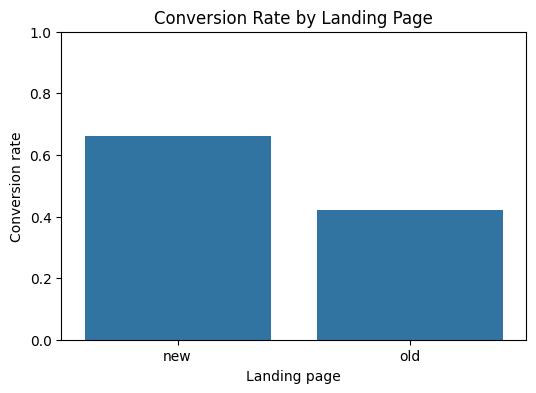

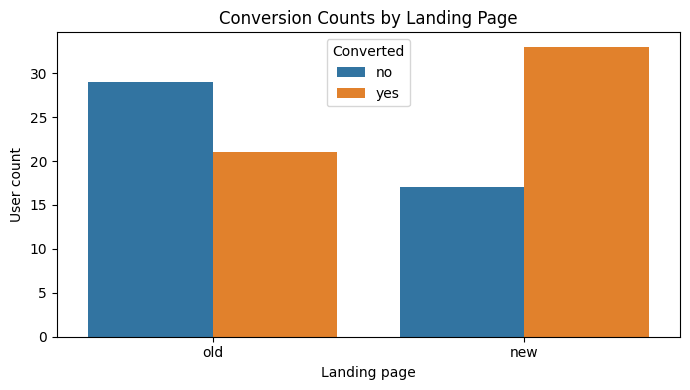

In [19]:
conv_rate_by_page = df.groupby("landing_page")["converted_flag"].mean().reset_index()

plt.figure(figsize=(6, 4))
sns.barplot(data=conv_rate_by_page, x="landing_page", y="converted_flag", errorbar=None)
plt.title("Conversion Rate by Landing Page")
plt.xlabel("Landing page")
plt.ylabel("Conversion rate")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="landing_page", hue="converted")
plt.title("Conversion Counts by Landing Page")
plt.xlabel("Landing page")
plt.ylabel("User count")
plt.legend(title="Converted")
plt.tight_layout()
plt.show()


#### Observations
- The new page achieves a higher conversion rate, significantly outperforming the old page's coversion rate.
- On the new page, conversions far outnumber non-conversions, whereas the old page had more failures than successes.

### **Formulate hypotheses**

### H0: p_new <= p_old
### H1: p_new >  p_old

### **Data collection & preparation**

In [20]:
page_summary = (
    df.groupby("landing_page")["converted_flag"]
      .agg(conversions="sum", visitors="count", conversion_rate="mean")
      .loc[["old", "new"]]
)

display(page_summary)

x_old = int(page_summary.loc["old", "conversions"])
n_old = int(page_summary.loc["old", "visitors"])
x_new = int(page_summary.loc["new", "conversions"])
n_new = int(page_summary.loc["new", "visitors"])

p_old = x_old / n_old
p_new = x_new / n_new

print(f"\nOld page: conversions={x_old}, visitors={n_old}, conversion_rate={p_old:.3f}")
print(f"New page: conversions={x_new}, visitors={n_new}, conversion_rate={p_new:.3f}")


,conversions,visitors,conversion_rate
landing_page,,,
old,21,50,0.42
new,33,50,0.66



Old page: conversions=21, visitors=50, conversion_rate=0.420
New page: conversions=33, visitors=50, conversion_rate=0.660


#### Observations
- The new landing page achieved a 66% conversion rate, significantly outperforming the old page's 42%.
- The new design represents a 24 percentage point increase in conversion effectiveness.

### **Selecting appropriate test**

In [21]:
# We are comparing two proportions from independent samples -> Two-proportion z-test.
# SciPy doesn't provide a direct helper in this environment; we compute z and p-value manually.

# Pooled proportion under H0
p_pool = (x_old + x_new) / (n_old + n_new)

# Standard error (pooled)
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_old + 1/n_new))

# z statistic for (p_new - p_old)
z_stat = (p_new - p_old) / se

# One-tailed p-value for H1: p_new > p_old
p_value = 1 - stats.norm.cdf(z_stat)

print("\nTest used: Two-proportion z-test (one-tailed: p_new > p_old)")
print(f"Pooled proportion = {p_pool:.4f}")
print(f"z-statistic = {z_stat:.4f}")
print(f"p-value (one-tailed) = {p_value:.6f}")


Test used: Two-proportion z-test (one-tailed: p_new > p_old)
Pooled proportion = 0.5400
z-statistic = 2.4077
p-value (one-tailed) = 0.008026


### **Inference based on p-value**

- Reject H0 at alpha=0.05.
- There is statistically significant evidence that the NEW page conversion rate is GREATER than the OLD page conversion rate.

## **Hypothesis Test 3 - Does the converted status depend on the preferred language?**

In [22]:
# Significance level (alpha)
alpha = 0.05

### **Visual analysis**

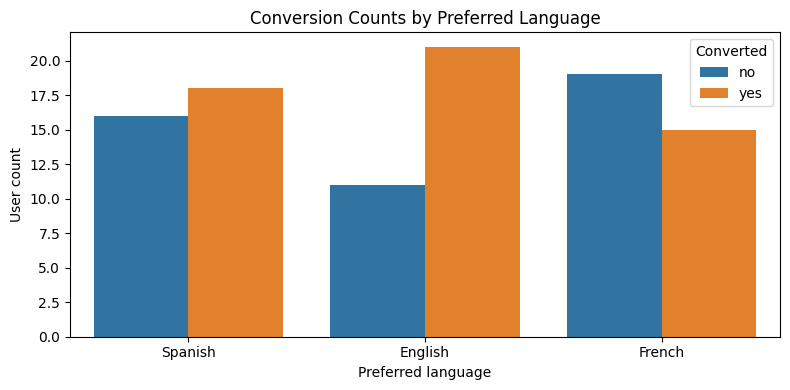

In [23]:
# Conversion counts by preferred language
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="language_preferred", hue="converted")
plt.title("Conversion Counts by Preferred Language")
plt.xlabel("Preferred language")
plt.ylabel("User count")
plt.legend(title="Converted")
plt.tight_layout()
plt.show()


#### Observations
- English speakers show the highest conversion performance, with successful conversions.
- French is the only language where non-conversions exceed conversions, indicating lower effectiveness for this group.
- Spanish speakers have a relatively balanced but positive trend, with slightly more conversions
- Conversion effectiveness is highest among English users and lowest among French users, suggesting a need for better localization or targeted content for the French-speaking audience.

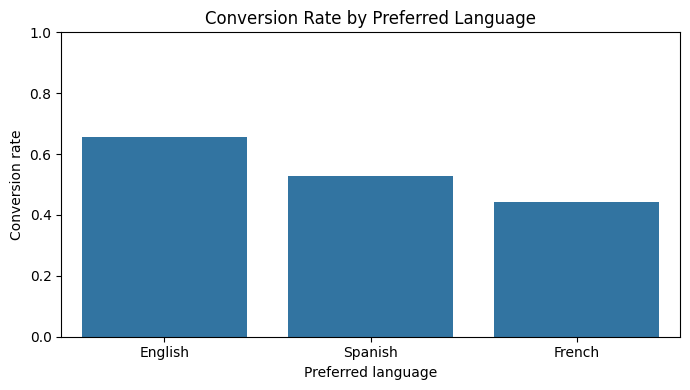

In [24]:
# Conversion rate by language
conv_rate_lang = (
    df.groupby("language_preferred")["converted_flag"]
      .mean()
      .reset_index()
      .sort_values("converted_flag", ascending=False)
)

plt.figure(figsize=(7, 4))
sns.barplot(data=conv_rate_lang, x="language_preferred", y="converted_flag", errorbar=None)
plt.title("Conversion Rate by Preferred Language")
plt.xlabel("Preferred language")
plt.ylabel("Conversion rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


#### Observations
- English speakers have the highest conversion rate, followed by Spanish speakers with French speakers having the lowest conversion rate.

### **Formulate hypotheses**

### H0: converted status is independent of preferred language
### H1: converted status depends on preferred language (not independent)

### **Data collection & preparation**

In [25]:
contingency = pd.crosstab(df["language_preferred"], df["converted"])
print("\nContingency table (language_preferred x converted):")
display(contingency)


Contingency table (language_preferred x converted):


converted,no,yes
language_preferred,,
English,11,21
French,19,15
Spanish,16,18


#### Observations
- Highest conversion success, with nearly double the number of conversions compared to non-conversions (21 vs. 11)
- Lowest performance, being the only language where non-conversions outnumber conversions (19 vs. 15).
- Shows a balanced but positive trend with slightly more conversions than non-conversions (18 vs. 16).
- Language preference is a key factor in conversion, with the current content most effective for English speakers and least effective for French speakers.

### **Selecting appropriate test**

In [26]:
# Two categorical variables -> Chi-square test of independence.
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print("\nTest used: Chi-square test of independence")
print(f"chi-square statistic = {chi2:.4f}")
print(f"degrees of freedom = {dof}")
print(f"p-value = {p_value:.6f}")



Test used: Chi-square test of independence
chi-square statistic = 3.0930
degrees of freedom = 2
p-value = 0.212989


### **Inference based on p-value**

- Fail to reject H0 at alpha=0.05.
- There is not enough statistical evidence to conclude that conversion status depends on preferred language.

## **Hypothesis Test 4 - Is the mean time spent on the NEW page the same for different language users?**

In [27]:
# Significance level (alpha)
alpha = 0.05

### **Data collection & preparation (NEW page only)**

In [28]:
df_new = df[df["landing_page"] == "new"].copy()

print("NEW page dataset shape:", df_new.shape)
print("\nSample size per language (NEW page only):")
display(df_new["language_preferred"].value_counts().to_frame("count"))

NEW page dataset shape: (50, 7)

Sample size per language (NEW page only):


,count
Spanish,17
French,17
English,16


### **Visual analysis**

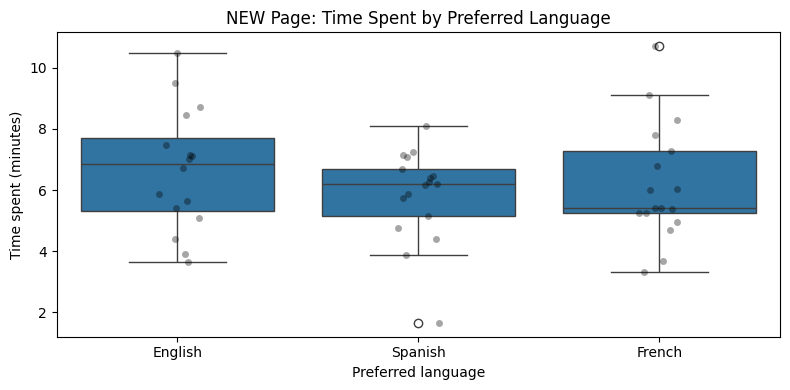

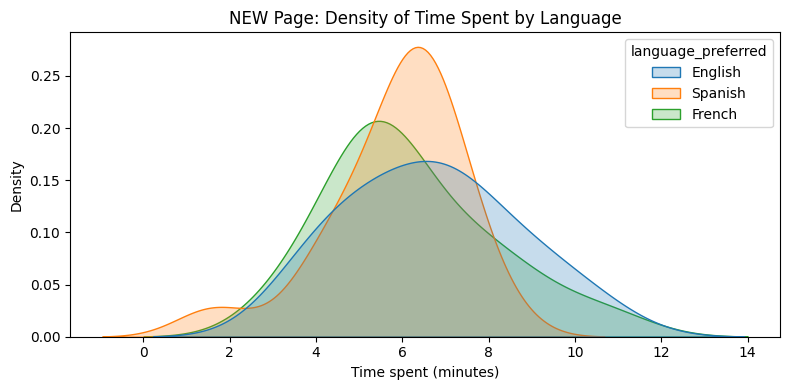


Summary (NEW page only) by language:


,count,mean,median,std,min,max
language_preferred,,,,,,
English,16,6.663750,6.865,1.984150,3.65,10.50
French,17,6.196471,5.420,1.933394,3.30,10.71
Spanish,17,5.835294,6.200,1.525656,1.65,8.08


In [29]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_new, x="language_preferred", y="time_spent_on_the_page")
sns.stripplot(data=df_new, x="language_preferred", y="time_spent_on_the_page", color="black", alpha=0.35)
plt.title("NEW Page: Time Spent by Preferred Language")
plt.xlabel("Preferred language")
plt.ylabel("Time spent (minutes)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.kdeplot(data=df_new, x="time_spent_on_the_page", hue="language_preferred", fill=True, common_norm=False, alpha=0.25)
plt.title("NEW Page: Density of Time Spent by Language")
plt.xlabel("Time spent (minutes)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

print("\nSummary (NEW page only) by language:")
display(
    df_new.groupby("language_preferred")["time_spent_on_the_page"]
          .agg(count="count", mean="mean", median="median", std="std", min="min", max="max")
          .sort_values("mean", ascending=False)
)


#### Observations
- English speakers spend the most time on the new page, with the highest mean (6.66 min) and median (6.86 min).
- Spanish users show the most uniform behavior, having the lowest standard deviation (1.52) and a highly peaked density distribution.
- French speakers have the lowest median engagement (5.42 min) but exhibit high variability, including notable high-engagement outliers.
- While the new page performs well across all groups, it is most effective at sustaining long-duration engagement with English-speaking users.

### **Formulate hypotheses**

### H0: Mean time spent on NEW page is the same for all languages (mu_Eng = mu_Spa = mu_Fre)
### H1: At least one language has a different mean time spent on NEW page

### **Selecting appropriate test**

In [30]:
# Prepare samples for ANOVA
samples = []
labels = []
for lang, sub in df_new.groupby("language_preferred"):
    samples.append(sub["time_spent_on_the_page"].dropna().values)
    labels.append(lang)

### **Calculate the p-value**

In [31]:
f_stat, p_value = stats.f_oneway(*samples)

print("\nTest used: One-way ANOVA (NEW page time ~ language)")
print(f"F-statistic = {f_stat:.4f}")
print(f"p-value = {p_value:.6f}")


Test used: One-way ANOVA (NEW page time ~ language)
F-statistic = 0.8544
p-value = 0.432041


### **Inference based on p-value**

- Fail to reject H0 at alpha=0.05.
- There is enough statistical evidence to say mean time on the NEW page differs by language.